In [2]:
from google.colab import drive
import os

# Mount your Google Drive
drive.mount('/content/drive')

# Change the working directory to your project folder
# This is where your .ipynb, Pretrained_models, and .json files are
%cd /content/drive/MyDrive/Transformer_Encoder/SwinBrain/

# List files to confirm you're in the right place
!ls

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Encoder/SwinBrain
dataset_split.json		  Models.py	     run_docker.sh
Final_PreProcess_SwinBrain.ipynb  persistent_cache   run_ssl_train.sh
Fine_tune_commented.ipynb	  Pretrained_models  segmentation_model
finetune_test.py		  README.md	     SwinUNETR_pretrain_DDP.py
finetune_train.py		  requirements.txt   workflow.jpg


In [3]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.7 MB/s eta 0:00:00


In [16]:
import json
import torch
import monai
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from monai.data import PersistentDataset, DataLoader, decollate_batch  # <--- CHANGE: Using PersistentDataset
from monai.inferers import sliding_window_inference                 # <--- CHANGE: For validation
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import (
    LoadImaged,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    RandCropByPosNegLabeld,
    AsDiscrete,
    MapLabelValued,
    CenterSpatialCropd,
)
from monai.utils import set_determinism

# --- 1. SETTINGS ---
set_determinism(seed=42)

# File paths
JSON_FILE = "dataset_split.json"
PRETRAINED_FILE = "Pretrained_models/SSL_SwinUNETR.pth"
MODEL_OUTPUT_DIR = "segmentation_model"
CACHE_DIR = "persistent_cache"  # <--- CHANGE: Directory for PersistentDataset
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# Training settings
ROI_SIZE = (128, 128, 64) # The 3D patch size
BATCH_SIZE = 1           # Load 1 full image at a time
OUT_CHANNELS = 2         # 2 classes: (0=Background, 1=Tumor)
LEARNING_RATE = 1e-4
MAX_EPOCHS = 150         # <--- CHANGE: Increased for full training

# Set the device (A100 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Settings loaded. Using device: {device}")
print(f"Will load data map from: {JSON_FILE}")
print(f"Will load weights from: {PRETRAINED_FILE}")

Settings loaded. Using device: cuda
Will load data map from: dataset_split.json
Will load weights from: Pretrained_models/SSL_SwinUNETR.pth


In [6]:
# --- 2. DATA LOADING & TRANSFORMS ---
print("Setting up data transforms...")

# Define MONAI transforms for training
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(
        keys=["label"],
        orig_labels=[1, 2, 3, 4],
        target_labels=[1, 1, 1, 1]
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0, a_max=2000,
        b_min=0.0, b_max=1.0,
        clip=True,
    ),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=1,
        neg=1,
        num_samples=4,  # <--- CHANGE: Increased batch size for A100
        image_key="image",
        image_threshold=0,
    ),
    EnsureTyped(keys=["image", "label"]),
])

# Define transforms for validation
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(
        keys=["label"],
        orig_labels=[1, 2, 3, 4],
        target_labels=[1, 1, 1, 1]
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0, a_max=2000,
        b_min=0.0, b_max=1.0,
        clip=True,
    ),

    # <--- CHANGE: Removed CenterSpatialCropd ---
    # We will now validate on the *entire* image using a sliding window.

    EnsureTyped(keys=["image", "label"]),
])

print(f"Transforms defined with label remapping and num_samples=4.")

Setting up data transforms...
Transforms defined with label remapping and num_samples=4.


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
print(f"Loading data from {JSON_FILE}...")
with open(JSON_FILE, 'r') as f:
    data_split = json.load(f)

train_files = data_split["train"]
val_files = data_split["validation"]
print(f"Found {len(train_files)} training file(s) and {len(val_files)} validation file(s).")

# --- CHANGE: Using PersistentDataset ---
# This caches processed data to your disk (in CACHE_DIR) instead of RAM.
# It's much safer for large datasets.
print("Creating PersistentDataset and DataLoader...")
train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=CACHE_DIR)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=CACHE_DIR)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)

print("DataLoaders are ready.")

Loading data from dataset_split.json...
Found 160 training file(s) and 40 validation file(s).
Creating PersistentDataset and DataLoader...
DataLoaders are ready.


In [8]:
# Grab one sample batch
sample_batch = next(iter(train_loader))
inputs, labels = sample_batch["image"], sample_batch["label"]

print("--- Data Pipeline Test ---")
print(f"Input batch shape: {inputs.shape}")
print(f"Label batch shape: {labels.shape}")

print("\nWhat this means:")
print(f"Your `RandCropByPosNegLabeld` transform created {inputs.shape[0]} samples.")
print(f"Your `BATCH_SIZE={BATCH_SIZE}` loader took those samples and stacked them.")
print("The shape is: [num_samples, channels, H, W, D]")

--- Data Pipeline Test ---
Input batch shape: torch.Size([4, 3, 128, 128, 64])
Label batch shape: torch.Size([4, 1, 128, 128, 64])

What this means:
Your `RandCropByPosNegLabeld` transform created 4 samples.
Your `BATCH_SIZE=1` loader took those samples and stacked them.
The shape is: [num_samples, channels, H, W, D]


In [9]:
# --- 3. MODEL, LOSS, & OPTIMIZER ---
print("Setting up SwinUNETR model...")

model = SwinUNETR(
    spatial_dims=3,          # Specify 3D model
    in_channels=3,         # 3 input channels (T1, T2w, T2f)
    out_channels=OUT_CHANNELS, # 2 output channels (BG, Tumor)
    feature_size=24,         # (CRITICAL FIX) Match architecture of pre-trained file
    use_checkpoint=True,
).to(device)

# --- Load the pre-trained weights ---
try:
    print(f"Loading pre-trained weights from {PRETRAINED_FILE}...")

    # Load weights onto the correct device (CPU or GPU)
    pretrained_weights = torch.load(PRETRAINED_FILE, map_location=device)

    model_state_dict = model.state_dict()
    clean_weights = {}

    # Clean keys (remove 'module.' prefix if it exists from multi-GPU training)
    for k, v in pretrained_weights.items():
        if k.startswith('module.'):
            clean_key = k[len('module.'):]
        else:
            clean_key = k

        if clean_key in model_state_dict:
            # Check if shapes match before adding
            if v.shape == model_state_dict[clean_key].shape:
                clean_weights[clean_key] = v

    # Load the cleaned weights, ignoring keys that don't match (e.g., decoder)
    model.load_state_dict(clean_weights, strict=False)
    print("✅ Successfully loaded pre-trained encoder weights.")
except Exception as e:
    print(f"⚠️ Warning: Could not load pre-trained weights. Error: {e}")

# --- Define Loss, Optimizer, and Metrics ---
# This loss combines Dice and Cross-Entropy
# to_onehot_y=True automatically converts our 1-channel label to 2 channels
# to match the model's 2-channel output.
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# Post-processing transforms to convert model output to a hard mask
post_pred = AsDiscrete(argmax=True, to_onehot=OUT_CHANNELS)
post_label = AsDiscrete(to_onehot=OUT_CHANNELS)

print("Model, Loss, and Optimizer are ready.")

Setting up SwinUNETR model...
Loading pre-trained weights from Pretrained_models/SSL_SwinUNETR.pth...
✅ Successfully loaded pre-trained encoder weights.
Model, Loss, and Optimizer are ready.


In [10]:
# --- Model Structure Test ---
print("Testing one forward pass...")
model.eval() # Set model to evaluation mode
with torch.no_grad(): # We don't need to calculate gradients for this test
    # Move the sample data to the GPU
    test_inputs = inputs.to(device)
    print(f"Sending input of shape: {test_inputs.shape} to model...")

    # Run the model
    test_outputs = model(test_inputs)

    print(f"\n--- Model Test Result ---")
    print(f"Received output shape: {test_outputs.shape}")
    print("\nWhat this means:")
    print(f"The model correctly took your [{inputs.shape[0]}, 3, ...] batch...")
    # --- THIS IS THE FIX ---
    print(f"...and produced an output of [{test_outputs.shape[0]}, {OUT_CHANNELS}, ...].")
    print("This is [batch, out_channels, H, W, D].")

Testing one forward pass...
Sending input of shape: torch.Size([4, 3, 128, 128, 64]) to model...

--- Model Test Result ---
Received output shape: torch.Size([4, 2, 128, 128, 64])

What this means:
The model correctly took your [4, 3, ...] batch...
...and produced an output of [4, 2, ...].
This is [batch, out_channels, H, W, D].


In [11]:
# --- Loss Calculation Test ---
print("Testing loss calculation...")

# Move labels to GPU (inputs/outputs are already on GPU from Cell 7)
test_labels = labels.to(device)
print(f"Output shape: {test_outputs.shape}")
print(f"Label shape: {test_labels.shape}")

# Calculate loss
loss = loss_function(test_outputs, test_labels)

print(f"\n✅ Loss calculated successfully: {loss.item():.4f}")

Testing loss calculation...
Output shape: torch.Size([4, 2, 128, 128, 64])
Label shape: torch.Size([4, 1, 128, 128, 64])

✅ Loss calculated successfully: 1.4392


Running ONE full epoch of training and validation...
Using device: cuda
  Train Step 1, Loss: 1.4212
  Train Step 2, Loss: 1.4275
  Train Step 3, Loss: 1.4172
  Train Step 4, Loss: 1.3845
  Train Step 5, Loss: 1.3583
  Train Step 6, Loss: 1.4067
  Train Step 7, Loss: 1.3232
  Train Step 8, Loss: 1.3423
  Train Step 9, Loss: 1.3008
  Train Step 10, Loss: 1.3618
  Train Step 11, Loss: 1.2941
  Train Step 12, Loss: 1.3541
  Train Step 13, Loss: 1.2634
  Train Step 14, Loss: 1.2560
  Train Step 15, Loss: 1.2652
  Train Step 16, Loss: 1.3110
  Train Step 17, Loss: 1.2158
  Train Step 18, Loss: 1.2160
  Train Step 19, Loss: 1.2138
  Train Step 20, Loss: 1.2251
  Train Step 21, Loss: 1.2144
  Train Step 22, Loss: 1.1939
  Train Step 23, Loss: 1.1779
  Train Step 24, Loss: 1.1756
  Train Step 25, Loss: 1.1710
  Train Step 26, Loss: 1.2105
  Train Step 27, Loss: 1.1482
  Train Step 28, Loss: 1.1551
  Train Step 29, Loss: 1.1754
  Train Step 30, Loss: 1.1687
  Train Step 31, Loss: 1.1190
  Train

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  out

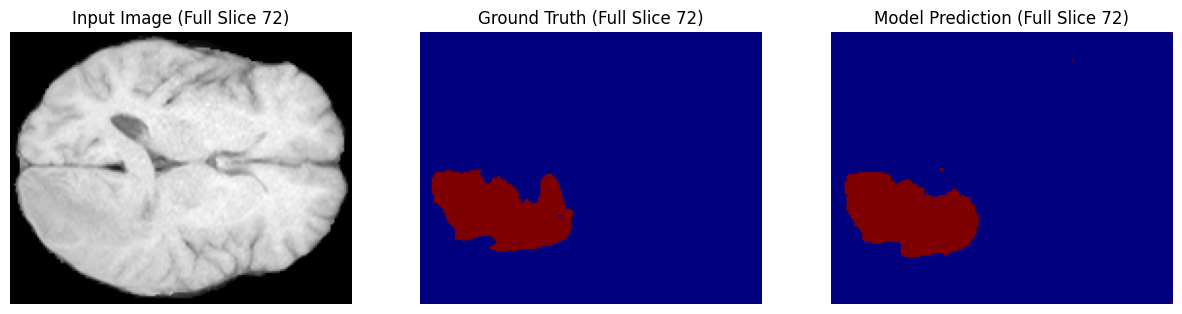

Epoch 1 average Dice: 0.8041

--- TEST COMPLETE ---


In [12]:
# --- 4. Single Epoch Training Test ---
print("Running ONE full epoch of training and validation...")
print(f"Using device: {device}")

# --- TRAINING STEP ---
model.train()
epoch_loss = 0
step = 0
for batch_data in train_loader:
    step += 1
    inputs, labels = (
        batch_data["image"].to(device),
        batch_data["label"].to(device),
    )
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_function(outputs, labels)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
    print(f"  Train Step {step}, Loss: {loss.item():.4f}")
print(f"Epoch 1 average training loss: {epoch_loss / step:.4f}")


# --- VALIDATION STEP (NEW) ---
print("\nRunning validation with sliding_window_inference...")
model.eval()
with torch.no_grad():

    val_data = next(iter(val_loader)) # Get the first validation image
    val_inputs, val_labels = (
        val_data["image"].to(device),
        val_data["label"].to(device),
    )

    # --- CHANGE: Use sliding_window_inference ---
    # This slides a 128x128x64 window across the *entire* image
    # and stitches the results together.
    val_outputs = sliding_window_inference(
        inputs=val_inputs,
        roi_size=ROI_SIZE,
        sw_batch_size=4,  # How many patches to process at once (for A100)
        predictor=model
    )

    # --- START OF VISUALIZATION CODE (UPDATED) ---

    # Get the middle slice of the *full* 3D volume
    slice_idx = val_inputs.shape[4] // 2

    # Get the T1 channel (channel 0)
    img_slice = val_inputs[0, 0, :, :, slice_idx].cpu().numpy()

    # Get the label (it's only 1 channel)
    label_slice = val_labels[0, 0, :, :, slice_idx].cpu().numpy()

    # Get the prediction (run argmax to get 1-channel mask)
    pred_slice = torch.argmax(val_outputs, dim=1)[0, :, :, slice_idx].cpu().numpy()

    # Plot them
    plt.figure("Validation Result", figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title(f"Input Image (Full Slice {slice_idx})")
    plt.imshow(img_slice, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Ground Truth (Full Slice {slice_idx})")
    plt.imshow(label_slice, cmap="jet")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Model Prediction (Full Slice {slice_idx})")
    plt.imshow(pred_slice, cmap="jet")
    plt.axis("off")

    plt.show()

    # --- END OF VISUALIZATION CODE ---

    # --- Calculate metric on the *full* image ---
    val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
    val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]
    dice_metric(y_pred=val_outputs_list, y=val_labels_list)
    metric = dice_metric.aggregate().item()
    dice_metric.reset()

print(f"Epoch 1 average Dice: {metric:.4f}")
print("\n--- TEST COMPLETE ---")

In [ ]:
# --- 5. FULL TRAINING LOOP ---
print(f"Starting full training on {device} for {MAX_EPOCHS} epochs...")

best_metric = -1
best_metric_epoch = -1
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

for epoch in range(MAX_EPOCHS):
    print("-" * 10)
    print(f"Epoch {epoch + 1}/{MAX_EPOCHS}")

    # --- Training Step ---
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    lr_scheduler.step()
    epoch_loss /= step
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # --- Validation Step (NEW) ---
    model.eval()
    with torch.no_grad():
        # Iterate over the *entire* validation set
        for val_data in val_loader:
            val_inputs, val_labels = (
                val_data["image"].to(device),
                val_data["label"].to(device),
            )

            # --- CHANGE: Use sliding_window_inference ---
            val_outputs = sliding_window_inference(
                inputs=val_inputs,
                roi_size=ROI_SIZE,
                sw_batch_size=4, # Patches per inference
                predictor=model
            )

            # Apply post-processing
            val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
            val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

            dice_metric(y_pred=val_outputs_list, y=val_labels_list)

        # Get the average Dice score for this epoch
        metric = dice_metric.aggregate().item()
        dice_metric.reset()

        print(f"Epoch {epoch + 1} average Dice: {metric:.4f}")

        # Save the best model
        if metric > best_metric:
            best_metric = metric
            best_metric_epoch = epoch + 1
            torch.save(
                model.state_dict(),
                os.path.join(MODEL_OUTPUT_DIR, "best_metric_model.pth"),
            )
            print("Saved new best metric model")

print("\n--- TRAINING COMPLETE ---")
print(f"Best Metric (Dice): {best_metric:.4f} at epoch {best_metric_epoch}")
print(f"Your best model is saved at: {MODEL_OUTPUT_DIR}/best_metric_model.pth")

Starting full training on cuda for 150 epochs...
----------
Epoch 1/150
Epoch 1 average loss: 0.3909
Epoch 1 average Dice: 0.4964
Saved new best metric model
----------
Epoch 2/150
Epoch 2 average loss: 0.3730
Epoch 2 average Dice: 0.5291
Saved new best metric model
----------
Epoch 3/150
Epoch 3 average loss: 0.3600
Epoch 3 average Dice: 0.5332
Saved new best metric model
----------
Epoch 4/150
Epoch 4 average loss: 0.3453
Epoch 4 average Dice: 0.5492
Saved new best metric model
----------
Epoch 5/150
Epoch 5 average loss: 0.3384
Epoch 5 average Dice: 0.5333
----------
Epoch 6/150
Epoch 6 average loss: 0.3255
Epoch 6 average Dice: 0.5215
----------
Epoch 7/150
Epoch 7 average loss: 0.3237
Epoch 7 average Dice: 0.5435
----------
Epoch 8/150
Epoch 8 average loss: 0.3204
Epoch 8 average Dice: 0.5612
Saved new best metric model
----------
Epoch 9/150
Epoch 9 average loss: 0.3067
Epoch 9 average Dice: 0.5544
----------
Epoch 10/150
Epoch 10 average loss: 0.3015
Epoch 10 average Dice: 0.528